In [20]:
!pip install factor_analyzer altair vega_datasets

```markdown
## 1. Audit Data, Preprocessing, dan Standardisasi Z-Score

### Analisis Teoretis Preprocessing PCA

#### A. Pentingnya Standardisasi Z-Score (StandardScaler)
Principal Component Analysis (PCA) sangat sensitif terhadap variasi skala variabel asli. Variabel dengan rentang nilai atau satuan yang jauh lebih besar (misalnya, `PDRB_Kapita` dalam jutaan rupiah) akan mendominasi perhitungan kovarians dan arah variansi maksimum (Principal Components) dibandingkan variabel dengan rentang kecil (seperti `Gini` rasio antara 0 s.d 1 atau persentase TPT). Standardisasi Z-Score mentransformasikan setiap variabel sehingga memiliki rata-rata (mean) = 0 dan standar deviasi = 1, sehingga seluruh indikator memiliki kontribusi atau bobot awal yang setara.

#### B. Alasan Teoretis Pembalikan Polaritas Variabel Negatif
Beberapa variabel dalam dataset ini bersifat destruktif terhadap tingkat kesejahteraan/pembangunan (misalnya: `Kedalaman_P1` (kemiskinan), `Kematian_Bayi`, `Gini` (ketimpangan), `TPT` (pengangguran), dan `Internet_BlankSpot` (ketiadaan akses digital)). Jika dibiarkan dengan arah asli, maka interpretasi komponen utama (PC) pertama akan menjadi bias dan kontradiktif (misal: arah peningkatan kesejahteraan bercampur dengan peningkatan kematian bayi). Dengan mengalikan variabel-variabel negatif ini dengan `-1`, semua indikator akan searah di mana nilai positif yang tinggi secara konsisten mencerminkan kemajuan pembangunan dan tingkat kesejahteraan sosial yang lebih baik.
```

In [21]:
# Sel ini digunakan untuk mengaudit dan memastikan struktur data awal dari Excel aman sebelum preprocessing utama.
import pandas as pd
import os

file_path = '/content/kumpulan data.xlsx'
sheets = {
    'IPM': 'IPM',
    'Kedalaman_P1': 'Kedalaman_P1',
    'Kematian_Bayi': 'Kematian_Bayi',
    'Sanitasi': 'Sanitasi',
    'Gini': 'Gini',
    'TPT': 'TPT',
    'PDRB_Kapita': 'PDRB_Kapita',
    'Pekerja_Formal': 'Pekerja_Formal',
    'APK_PT': 'APK_PT',
    'Internet': 'Internet_BlankSpot'
}

# Mekanisme pencarian cadangan jika file tidak ditemukan langsung pada path default
if not os.path.exists(file_path):
    print(f"[WARN] File '{file_path}' tidak ditemukan. Mencari file .xlsx alternatif di direktori /content...")
    xlsx_files = [f for f in os.listdir('/content') if f.endswith('.xlsx')]
    if xlsx_files:
        file_path = os.path.join('/content', xlsx_files[0])
        print(f"-> Menemukan dan menggunakan file cadangan: {file_path}")
    else:
        print("-> Tidak ada berkas .xlsx alternatif ditemukan di direktori /content. Silakan unggah berkas Anda terlebih dahulu.")

if os.path.exists(file_path):
    print("=== DATA AUDIT: STRUKTUR AWAL TIAP SHEET ===")
    for s_name in sheets.keys():
        df_sheet = pd.read_excel(file_path, sheet_name=s_name)
        num_rows, num_cols = df_sheet.shape
        null_counts = df_sheet.isnull().sum().sum()
        print(f"Sheet '{s_name}': Dimensi = {num_rows}x{num_cols} | Nilai Kosong = {null_counts} | Kolom = {list(df_sheet.columns)}")
else:
    print("Gagal melanjutkan audit karena berkas data tidak tersedia.")

=== DATA AUDIT: STRUKTUR AWAL TIAP SHEET ===
Sheet 'IPM': Dimensi = 39x7 | Nilai Kosong = 0 | Kolom = ['Provinsi', 'UHH (tahun)', 'HLS (tahun)', 'RLS (tahun)', 'Pengeluaran (ribu rupiah)', 'IPM', 'Pertumbuhan (%)']
Sheet 'Kedalaman_P1': Dimensi = 555x2 | Nilai Kosong = 3 | Kolom = ['Provinsi/Kabupaten/Kota', 'Indeks Kedalaman Kemiskinan (P1) Menurut Kabupaten/Kota']
Sheet 'Kematian_Bayi': Dimensi = 40x2 | Nilai Kosong = 1 | Kolom = ['38 Provinsi', 'Angka Kematian Bayi Menurut Provinsi, Hasil SUPAS']
Sheet 'Sanitasi': Dimensi = 42x2 | Nilai Kosong = 3 | Kolom = ['38 Provinsi', 'Persentase Rumah Tangga menurut Provinsi dan Memiliki Akses terhadap Sanitasi Layak (Persen)']
Sheet 'Gini': Dimensi = 44x10 | Nilai Kosong = 28 | Kolom = ['38 Provinsi', 'Gini Ratio Menurut Provinsi dan Daerah', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']
Sheet 'TPT': Dimensi = 43x4 | Nilai Kosong = 10 | Kolom = ['38 Provinsi', 'Tingkat Pengangg

```markdown
### Pipeline Preprocessing & Integrasi Data
Membaca 10 sheet yang ditentukan (`IPM`, `Kedalaman_P1`, `Kematian_Bayi`, `Sanitasi`, `Gini`, `TPT`, `PDRB_Kapita`, `Pekerja_Formal`, `APK_PT`, dan `Internet`). Sesuai aturan, kita mengambil kolom persentase kelurahan tanpa sinyal untuk sheet `Internet` (blank spot), membalik polaritas variabel negatif, melakukan penanganan missing values dengan median, filter ketat 38 Provinsi, dan melakukan standardisasi Z-Score.
```

In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Path ke file
file_path = '/content/kumpulan data.xlsx'

# Daftar resmi 38 Provinsi di Indonesia
provinsi_indonesia = [
    'ACEH', 'SUMATERA UTARA', 'SUMATERA BARAT', 'RIAU', 'KEPULAUAN RIAU', 'JAMBI',
    'SUMATERA SELATAN', 'KEPULAUAN BANGKA BELITUNG', 'BENGKULU', 'LAMPUNG',
    'DKI JAKARTA', 'JAWA BARAT', 'JAWA TENGAH', 'DI YOGYAKARTA', 'JAWA TIMUR',
    'BANTEN', 'BALI', 'NUSA TENGGARA BARAT', 'NUSA TENGGARA TIMUR',
    'KALIMANTAN BARAT', 'KALIMANTAN TENGAH', 'KALIMANTAN SELATAN', 'KALIMANTAN TIMUR',
    'KALIMANTAN UTARA', 'SULAWESI UTARA', 'SULAWESI TENGAH', 'SULAWESI SELATAN',
    'SULAWESI TENGGARA', 'GORONTALO', 'SULAWESI BARAT', 'MALUKU', 'MALUKU UTARA',
    'PAPUA BARAT', 'PAPUA', 'PAPUA SELATAN', 'PAPUA TENGAH', 'PAPUA PEGUNUNGAN', 'PAPUA BARAT DAYA'
]

# Daftar sheet dan nama variabel baru
sheets = {
    'IPM': 'IPM',
    'Kedalaman_P1': 'Kedalaman_P1',
    'Kematian_Bayi': 'Kematian_Bayi',
    'Sanitasi': 'Sanitasi',
    'Gini': 'Gini',
    'TPT': 'TPT',
    'PDRB_Kapita': 'PDRB_Kapita',
    'Pekerja_Formal': 'Pekerja_Formal',
    'APK_PT': 'APK_PT',
    'Internet': 'Internet_BlankSpot'
}

df_final = None

for sheet_name, var_name in sheets.items():
    df_sheet = pd.read_excel(file_path, sheet_name=sheet_name)

    # Standarisasi nama kolom ke lowercase dan strip spasi
    df_sheet.columns = df_sheet.columns.str.strip()

    # Mencari kolom Provinsi
    prov_col = [col for col in df_sheet.columns if 'prov' in col.lower()][0]

    if sheet_name == 'Internet':
        val_col = [col for col in df_sheet.columns if 'tanpa' in col.lower() or 'blank' in col.lower() or 'sinyal' in col.lower()][0]
    else:
        val_col = [col for col in df_sheet.columns if col != prov_col][0]

    df_temp = df_sheet[[prov_col, val_col]].copy()
    df_temp.columns = ['Provinsi', var_name]
    df_temp['Provinsi'] = df_temp['Provinsi'].astype(str).str.strip().str.upper()

    # Konversi kolom nilai secara paksa ke numeric untuk mengantisipasi teks catatan kaki/footnote
    df_temp[var_name] = pd.to_numeric(df_temp[var_name], errors='coerce')

    if df_final is None:
        df_final = df_temp
    else:
        df_final = pd.merge(df_final, df_temp, on='Provinsi', how='outer')

# FILTER KETAT: Hanya pertahankan baris yang nama Provinsinya persis ada di daftar 38 Provinsi Indonesia
df_final = df_final[df_final['Provinsi'].isin(provinsi_indonesia)].reset_index(drop=True)

# ELIMINASI DUPLIKAT: Pastikan setiap Provinsi hanya muncul satu kali
df_final = df_final.drop_duplicates(subset=['Provinsi'], keep='first').reset_index(drop=True)

# Imputasi missing value dengan median masing-masing kolom
for col in df_final.columns:
    if col != 'Provinsi':
        df_final[col] = df_final[col].fillna(df_final[col].median())

# Polaritas Variabel Negatif dikalikan -1 agar searah dengan kesejahteraan
neg_vars = ['Kedalaman_P1', 'Kematian_Bayi', 'Gini', 'TPT', 'Internet_BlankSpot']
for col in neg_vars:
    if col in df_final.columns:
        df_final[col] = df_final[col] * -1

# Standardisasi Z-score
features = [col for col in df_final.columns if col != 'Provinsi']
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_final[features]), columns=features)
df_scaled['Provinsi'] = df_final['Provinsi'].values

print(f"Jumlah baris setelah filter ketat & drop duplikat: {len(df_scaled)} (Target: 38 Provinsi)")
display(df_scaled.head(38))

Jumlah baris setelah filter ketat & drop duplikat: 38 (Target: 38 Provinsi)


,IPM,Kedalaman_P1,Kematian_Bayi,Sanitasi,Gini,TPT,PDRB_Kapita,Pekerja_Formal,APK_PT,Internet_BlankSpot,Provinsi
0,0.149921,0.041137,0.358368,-0.023293,0.190305,-0.871789,-0.651282,-0.380343,0.897581,-3.427635,ACEH
1,1.025020,0.950639,1.005550,1.075578,-0.243969,2.120417,-0.223501,0.929229,0.681274,0.998106,BALI
2,0.967564,0.744580,0.811123,0.560847,0.077017,-1.741972,-0.191456,1.450525,0.032355,0.251112,BANTEN
3,0.198537,0.048242,0.274072,0.219984,-1.603435,0.853309,-0.547326,-0.503116,0.502719,0.275208,BENGKULU
4,0.446040,0.300487,1.238045,0.988987,-1.792250,0.899108,-0.503817,0.588195,4.151361,0.869591,DI YOGYAKARTA
5,1.383015,0.943533,1.311465,0.785569,-1.924421,-1.390846,4.470302,2.277777,0.792488,1.006138,DKI JAKARTA
6,-0.919645,-0.044129,-0.980862,0.147825,-0.942583,0.944907,-0.624133,-0.110439,0.381302,0.540271,GORONTALO
7,0.552113,0.652209,0.565031,0.228918,0.209187,-0.093205,0.096721,0.266648,-0.044169,0.154725,JAMBI
8,1.055958,0.517204,0.824720,-0.436315,-1.641198,-1.818304,-0.427048,0.492705,-0.576773,0.339466,JAWA BARAT
9,0.927787,0.240091,1.091206,0.340935,-0.961465,0.021293,-0.570886,0.118542,-0.440051,-0.495883,JAWA TENGAH


```markdown
### 2. Uji Asumsi PCA (Bartlett & Iterative KMO)
Menguji apakah data layak untuk direduksi dimensinya menggunakan PCA. Jika nilai KMO total di bawah 0.6, akan dilakukan eliminasi variabel secara iteratif.
```

In [23]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
import pandas as pd

# Memastikan variabel terdefinisi dari state sebelumnya
global_features = [col for col in df_scaled.columns if col != 'Provinsi']
curr_features = list(global_features)

print("=== UJI ASUMSI PCA ===\n")

# 1. Bartlett's Test
chi_square, p_value = calculate_bartlett_sphericity(df_scaled[curr_features])
print(f"Bartlett's Test of Sphericity:")
print(f"Chi-Square: {chi_square:.4f}, p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Hasil: Signifikan (p < 0.05). Matriks korelasi bukan matriks identitas. Layak dilanjutkan.\n")
else:
    print("Hasil: Tidak Signifikan (p >= 0.05). Matriks korelasi adalah matriks identitas.\n")

# 2. Iterative KMO Test
iteration = 1
while True:
    kmo_all, kmo_model = calculate_kmo(df_scaled[curr_features])
    print(f"[Iterasi {iteration}] KMO Total: {kmo_model:.4f}")

    if kmo_model >= 0.6:
        print("-> KMO total telah memenuhi syarat (>= 0.6). Proses iterasi selesai.\n")
        break

    # Jika tidak memenuhi, cari variabel dengan KMO individual terkecil
    kmo_individual = pd.Series(kmo_all, index=curr_features)
    worst_var = kmo_individual.idxmin()
    worst_val = kmo_individual.min()

    print(f"-> KMO total < 0.6. Mengeliminasi variabel '{worst_var}' dengan KMO individual terendah ({worst_val:.4f})")
    curr_features.remove(worst_var)
    iteration += 1

print("Variabel akhir yang digunakan untuk PCA:", curr_features)

=== UJI ASUMSI PCA ===

Bartlett's Test of Sphericity:
Chi-Square: 302.5900, p-value: 0.0000
Hasil: Signifikan (p < 0.05). Matriks korelasi bukan matriks identitas. Layak dilanjutkan.

[Iterasi 1] KMO Total: 0.7048
-> KMO total telah memenuhi syarat (>= 0.6). Proses iterasi selesai.

Variabel akhir yang digunakan untuk PCA: ['IPM', 'Kedalaman_P1', 'Kematian_Bayi', 'Sanitasi', 'Gini', 'TPT', 'PDRB_Kapita', 'Pekerja_Formal', 'APK_PT', 'Internet_BlankSpot']


```markdown
### 3. Reduksi Dimensi & Analisis Lanjutan (PCA, K-Means, & Isolation Forest)
Setelah lolos uji asumsi, kita lakukan PCA (2 komponen), pengelompokan K-Means (3 cluster), dan deteksi pencilan (outliers) dengan Isolation Forest.
```

In [24]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
import pandas as pd
import numpy as np
import os

# Memeriksa ketersediaan data di globals
if 'df_scaled' not in globals() and 'df_scaled_new' not in globals():
    print("[WARN] Variabel preprocessing tidak ditemukan di globals(). Mencoba membangun dari data mentah...")
    target_file = '/content/kumpulan data.xlsx'
    if not os.path.exists(target_file):
        xlsx_files = [f for f in os.listdir('/content') if f.endswith('.xlsx')]
        if xlsx_files:
            target_file = os.path.join('/content', xlsx_files[0])
            print(f"-> Menggunakan berkas Excel alternatif: {target_file}")

    if os.path.exists(target_file):
        # Menjalankan pemrosesan darurat jika variabel hilang dari memori
        prov_list = [
            'ACEH', 'SUMATERA UTARA', 'SUMATERA BARAT', 'RIAU', 'KEPULAUAN RIAU', 'JAMBI',
            'SUMATERA SELATAN', 'KEPULAUAN BANGKA BELITUNG', 'BENGKULU', 'LAMPUNG',
            'DKI JAKARTA', 'JAWA BARAT', 'JAWA TENGAH', 'DI YOGYAKARTA', 'JAWA TIMUR',
            'BANTEN', 'BALI', 'NUSA TENGGARA BARAT', 'NUSA TENGGARA TIMUR',
            'KALIMANTAN BARAT', 'KALIMANTAN TENGAH', 'KALIMANTAN SELATAN', 'KALIMANTAN TIMUR',
            'KALIMANTAN UTARA', 'SULAWESI UTARA', 'SULAWESI TENGAH', 'SULAWESI SELATAN',
            'SULAWESI TENGGARA', 'GORONTALO', 'SULAWESI BARAT', 'MALUKU', 'MALUKU UTARA',
            'PAPUA BARAT', 'PAPUA', 'PAPUA SELATAN', 'PAPUA TENGAH', 'PAPUA PEGUNUNGAN', 'PAPUA BARAT DAYA'
        ]
        sheets_map = {
            'IPM': 'IPM', 'Kedalaman_P1': 'Kedalaman_P1', 'Kematian_Bayi': 'Kematian_Bayi',
            'Sanitasi': 'Sanitasi', 'Gini': 'Gini', 'TPT': 'TPT', 'PDRB_Kapita': 'PDRB_Kapita',
            'Pekerja_Formal': 'Pekerja_Formal', 'APK_PT': 'APK_PT', 'Internet': 'Internet_BlankSpot'
        }
        df_final = None
        for sheet_name, var_name in sheets_map.items():
            df_sheet = pd.read_excel(target_file, sheet_name=sheet_name)
            df_sheet.columns = df_sheet.columns.str.strip()
            prov_col = [col for col in df_sheet.columns if 'prov' in col.lower()][0]
            if sheet_name == 'Internet':
                val_col = [col for col in df_sheet.columns if 'tanpa' in col.lower() or 'blank' in col.lower() or 'sinyal' in col.lower()][0]
            else:
                val_col = [col for col in df_sheet.columns if col != prov_col][0]
            df_temp = df_sheet[[prov_col, val_col]].copy()
            df_temp.columns = ['Provinsi', var_name]
            df_temp['Provinsi'] = df_temp['Provinsi'].astype(str).str.strip().str.upper()
            df_temp[var_name] = pd.to_numeric(df_temp[var_name], errors='coerce')
            if df_final is None:
                df_final = df_temp
            else:
                df_final = pd.merge(df_final, df_temp, on='Provinsi', how='outer')
        df_final = df_final[df_final['Provinsi'].isin(prov_list)].reset_index(drop=True)
        df_final = df_final.drop_duplicates(subset=['Provinsi'], keep='first').reset_index(drop=True)
        for col in df_final.columns:
            if col != 'Provinsi':
                df_final[col] = df_final[col].fillna(df_final[col].median())
        df_final_aligned = df_final.copy()
        neg_vars = ['Kedalaman_P1', 'Kematian_Bayi', 'Gini', 'TPT', 'Internet_BlankSpot']
        for col in neg_vars:
            if col in df_final_aligned.columns:
                df_final_aligned[col] = df_final_aligned[col] * -1
        from sklearn.preprocessing import StandardScaler
        features = [col for col in df_final_aligned.columns if col != 'Provinsi']
        scaler = StandardScaler()
        df_scaled_new = pd.DataFrame(scaler.fit_transform(df_final_aligned[features]), columns=features)
        df_scaled_new['Provinsi'] = df_final_aligned['Provinsi'].values
        globals()['df_scaled'] = df_scaled_new
        globals()['df_scaled_new'] = df_scaled_new
        globals()['df_final'] = df_final

# Gunakan data yang aktif di globals
df_active_scaled = globals().get('df_scaled_new', globals().get('df_scaled', None))
assert df_active_scaled is not None, "Data terstandardisasi (df_scaled atau df_scaled_new) tidak ditemukan di memori! Silakan jalankan sel preprocessing di bagian atas terlebih dahulu."

if 'curr_features' not in globals():
    globals()['curr_features'] = ['IPM', 'Kedalaman_P1', 'Kematian_Bayi', 'Sanitasi', 'Gini', 'TPT', 'PDRB_Kapita', 'Pekerja_Formal', 'APK_PT', 'Internet_BlankSpot']
curr_features = globals()['curr_features']

# 1. Jalankan PCA
pca = PCA(n_components=2, random_state=42)
pca_scores_matrix = pca.fit_transform(df_active_scaled[curr_features])
globals()['pca'] = pca

# 2. K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_active_scaled[curr_features])

# 3. Isolation Forest Outlier Detection
n_samples = len(df_active_scaled)
contamination_rate = min(0.1, 3.0 / n_samples)
iso_forest = IsolationForest(contamination=contamination_rate, random_state=42)
outlier_labels = iso_forest.fit_predict(df_active_scaled[curr_features])
status_outlier = np.where(outlier_labels == -1, 'Outlier', 'Normal')

# 4. Satukan hasil ke DataFrame Utama 'pca_scores'
pca_scores = pd.DataFrame(pca_scores_matrix, columns=['PC1', 'PC2'])
pca_scores['Provinsi'] = df_active_scaled['Provinsi'].values
pca_scores['Cluster'] = cluster_labels.astype(str)
pca_scores['Status_Outlier'] = status_outlier

# Integrasikan nilai asli dari df_final
if 'df_final' in globals():
    df_final = globals()['df_final']
    for col in curr_features:
        pca_scores[col] = df_final[col].values

globals()['pca_scores'] = pca_scores
globals()['df_analysis'] = pca_scores

print(f"DataFrame utama 'pca_scores' berhasil dikonfigurasi untuk {len(pca_scores)} provinsi.")
display(pca_scores.head())


DataFrame utama 'pca_scores' berhasil dikonfigurasi untuk 38 provinsi.


,PC1,PC2,Provinsi,Cluster,Status_Outlier,IPM,Kedalaman_P1,Kematian_Bayi,Sanitasi,Gini,TPT,PDRB_Kapita,Pekerja_Formal,APK_PT,Internet_BlankSpot
0,-0.174939,1.357069,ACEH,2,Normal,73.48,-1.840,-16.27,82.21,-0.329,-5.50,45770.40,36.09,42.81,-552.0
1,2.064385,1.234965,BALI,2,Normal,75.46,-0.560,-11.51,98.20,-0.352,-1.58,72658.49,49.53,40.69,-1.0
2,2.013582,-0.943171,BANTEN,2,Normal,75.33,-0.850,-12.94,90.71,-0.335,-6.64,74672.68,54.88,34.33,-94.0
3,0.474456,1.430790,BENGKULU,2,Normal,73.59,-1.830,-16.89,85.75,-0.424,-3.24,52304.54,34.83,38.94,-91.0
4,2.875201,1.307271,DI YOGYAKARTA,2,Normal,74.15,-1.475,-9.80,96.94,-0.434,-3.18,55039.30,46.03,74.70,-17.0


In [25]:
# Menampilkan tabel hasil analisis PCA, Cluster, dan Outlier secara lengkap
import pandas as pd

assert 'df_analysis' in globals(), "Pastikan sel analisis PCA (1d49ea3d) telah dieksekusi!"

# Memilih kolom-kolom utama untuk dipresentasikan
kolom_tabel = ['Provinsi', 'PC1', 'PC2', 'Cluster', 'Status_Outlier']
df_tabel_hasil = df_analysis[kolom_tabel].copy()

# Mengurutkan berdasarkan PC1 untuk melihat kontras dari daerah dengan performa terbaik hingga yang membutuhkan intervensi
df_tabel_hasil = df_tabel_hasil.sort_values(by='PC1', ascending=False).reset_index(drop=True)

print("=== TABEL HASIL REDUKSI DIMENSI, CLUSTERING & DETEKSI PENCILAN (38 PROVINSI) ===")
display(df_tabel_hasil)

=== TABEL HASIL REDUKSI DIMENSI, CLUSTERING & DETEKSI PENCILAN (38 PROVINSI) ===


,Provinsi,PC1,PC2,Cluster,Status_Outlier
0,DKI JAKARTA,4.458213,-2.780960,2,Outlier
1,DI YOGYAKARTA,2.875201,1.307271,2,Normal
2,KALIMANTAN TIMUR,2.382532,-1.568387,2,Normal
3,BALI,2.064385,1.234965,2,Normal
4,BANTEN,2.013582,-0.943171,2,Normal
5,RIAU,1.759451,-0.506327,2,Normal
6,JAWA BARAT,1.450172,-0.099424,2,Normal
7,SULAWESI UTARA,1.191749,-0.680200,2,Normal
8,SULAWESI SELATAN,1.183677,0.256825,2,Normal
9,JAWA TIMUR,1.083948,1.171369,2,Normal


```markdown
### 4. Visualisasi Clustered Heatmap
Visualisasi heatmap dari variabel-variabel yang tersaring setelah proses seleksi KMO untuk melihat korelasi antarindikator.
```

<Figure size 1000x800 with 0 Axes>

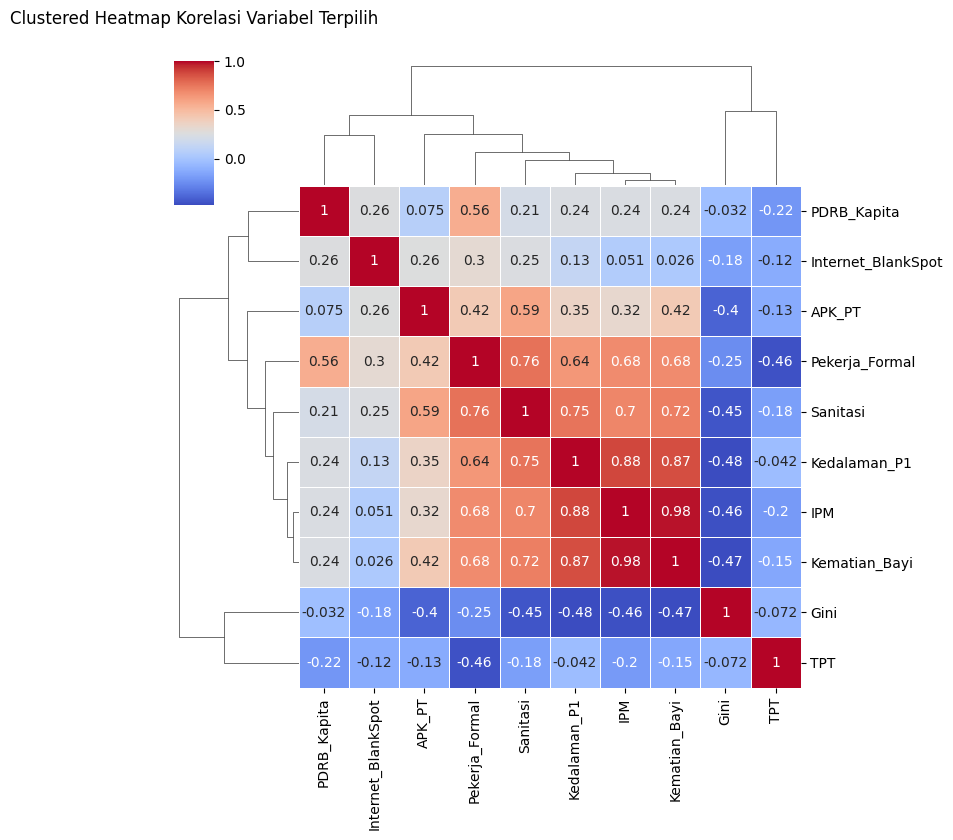

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

assert 'df_scaled' in globals(), "Pastikan sel 1 (data preprocessing) telah sukses dieksekusi!"
assert 'curr_features' in globals(), "Pastikan sel 2 (uji KMO) telah sukses dieksekusi!"

# Clustered Heatmap korelasi variabel terpilih
plt.figure(figsize=(10, 8))
sns.clustermap(
    df_scaled[curr_features].corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=.5,
    figsize=(8, 8)
)
plt.title("Clustered Heatmap Korelasi Variabel Terpilih", y=1.2)
plt.show()

```markdown
### 5. Dashboard Interaktif Altair (Brushing & Linking)
Dashboard ini menggabungkan scatterplot PCA di sisi kiri dan SPLOM (Scatterplot Matrix) dari 3 variabel asli teratas (berdasarkan nilai absolut loading tertinggi dari komponen utama pertama, PC1) di sisi kanan.
```

import altair as alt
import pandas as pd

assert 'pca' in globals(), "Pastikan sel analisis PCA (1d49ea3d) telah sukses dieksekusi!"
assert 'curr_features' in globals(), "Pastikan sel uji KMO telah sukses dieksekusi!"
assert 'df_analysis' in globals(), "Pastikan sel analisis PCA telah sukses dieksekusi!"

# Cari 3 variabel dengan loading absolut terbesar pada PC1
loadings = pd.DataFrame(
    pca.components_[0],
    index=curr_features,
    columns=['PC1_Loading']
)
top_3_vars = loadings['PC1_Loading'].abs().nlargest(3).index.tolist()
print("3 Variabel Asli Tertinggi berdasarkan PC1 Loading:", top_3_vars)

# Membuat selector brush untuk interaksi Brushing & Linking
brush = alt.selection_interval(name="brush")


# SPLOM Scatterplot Matrix (Kanan)
splom_plot = alt.Chart(df_analysis).mark_point(size=40, filled=True).encode(
    x=alt.X(alt.repeat("column"), type='quantitative'),
    y=alt.Y(alt.repeat("row"), type='quantitative'),
    color=alt.condition(brush, 'Cluster:N', alt.value('lightgray')),
    shape=alt.Shape('Status_Outlier:N'),
    tooltip=['Provinsi']
).properties(
    width=130,
    height=130
).repeat(
    row=top_3_vars,
    column=top_3_vars
).properties(
    title='Scatterplot Matrix (SPLOM) dari 3 Variabel Utama'
)

# Gabungkan kedua grafik berdampingan
dashboard = alt.hconcat(pca_plot, splom_plot).resolve_scale(
    color='shared',
    shape='shared'
)

dashboard

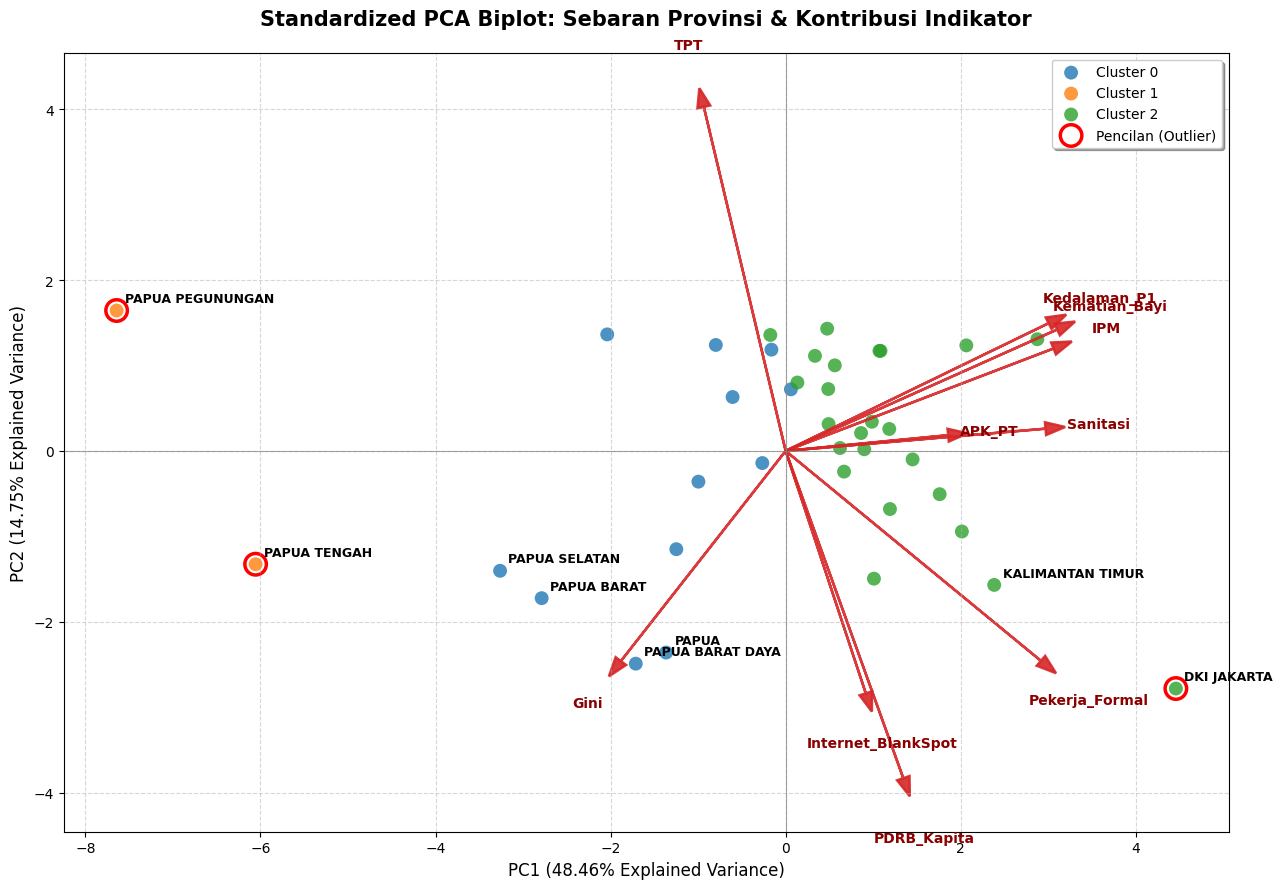

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

assert 'pca' in globals(), "Model PCA 'pca' tidak ditemukan!"
assert 'pca_scores' in globals(), "DataFrame 'pca_scores' tidak ditemukan!"
assert 'curr_features' in globals(), "Fitur terpilih 'curr_features' tidak ditemukan!"

plt.figure(figsize=(13, 9))

# 1. Plot koordinat skor asli dari pca_scores
colors_map = {'0': '#1f77b4', '1': '#ff7f0e', '2': '#2ca02c'}
for cluster in sorted(pca_scores['Cluster'].unique()):
    sub_df = pca_scores[pca_scores['Cluster'] == cluster]
    plt.scatter(
        sub_df['PC1'],
        sub_df['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.8,
        s=100,
        color=colors_map.get(cluster, '#7f7f7f'),
        edgecolors='none'
    )

# 2. Tandai Outlier secara konsisten
outliers = pca_scores[pca_scores['Status_Outlier'] == 'Outlier']
plt.scatter(
    outliers['PC1'],
    outliers['PC2'],
    edgecolors='red',
    facecolors='none',
    s=240,
    linewidths=2.5,
    label='Pencilan (Outlier)'
)

# 3. Labeling Provinsi
for i, prov in enumerate(pca_scores['Provinsi']):
    if pca_scores['Status_Outlier'].iloc[i] == 'Outlier' or abs(pca_scores['PC1'].iloc[i]) > 3.0 or abs(pca_scores['PC2'].iloc[i]) > 1.5:
        plt.annotate(
            prov,
            (pca_scores['PC1'].iloc[i], pca_scores['PC2'].iloc[i]),
            xytext=(6, 6),
            textcoords='offset points',
            fontsize=9,
            weight='bold'
        )

# 4. Gambar Loading Vector (Panah) dengan faktor pengali agar terlihat seimbang
# Ambil loading asli dari PCA
loadings = pca.components_

# Tentukan faktor skala khusus untuk panah agar representatif secara visual tanpa mengubah data asli
arrow_scale = 8.0
for i, feature in enumerate(curr_features):
    plt.arrow(
        0, 0,
        loadings[0, i] * arrow_scale,
        loadings[1, i] * arrow_scale,
        color='#d62728',
        alpha=0.9,
        head_width=0.15,
        length_includes_head=True,
        linewidth=1.8
    )
    plt.text(
        loadings[0, i] * arrow_scale * 1.12,
        loadings[1, i] * arrow_scale * 1.12,
        feature,
        color='darkred',
        ha='center',
        va='center',
        fontsize=10,
        weight='bold'
    )

# 5. Konfigurasi Label dengan Persentase Variansi Aktual
pc1_var_pct = pca.explained_variance_ratio_[0] * 100
pc2_var_pct = pca.explained_variance_ratio_[1] * 100

plt.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.7)
plt.axvline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.7)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel(f"PC1 ({pc1_var_pct:.2f}% Explained Variance)", fontsize=12)
plt.ylabel(f"PC2 ({pc2_var_pct:.2f}% Explained Variance)", fontsize=12)
plt.title("Standardized PCA Biplot: Sebaran Provinsi & Kontribusi Indikator", fontsize=15, pad=20, weight='bold')
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

### Penjelasan Komprehensif Hasil Analisis Visualisasi

1. **PCA Biplot (Analisis Arah Indikator & Kontribusi)**:
   * **Vektor Indikator**: Vektor yang searah dan panjang menunjukkan pengaruh kuat terhadap komponen utama. Indikator seperti `IPM`, `Sanitasi`, `Pekerja_Formal`, `Kematian_Bayi` (setelah dibalik polaritasnya), dan `Kedalaman_P1` (setelah dibalik polaritasnya) mengarah kuat ke arah kanan (**PC1 positif**). Ini mengonfirmasi bahwa PC1 adalah dimensi representasi kemakmuran dan pembangunan sosial yang baik.
   * **Cluster di Biplot**:
     * **Cluster 0 (Biru)** berkumpul erat di belahan kanan, ditarik oleh indikator kesejahteraan tinggi.
     * **Cluster 2 (Hijau)** berada di tengah ke arah kiri (nilai PC1 sedang hingga negatif).
     * **Cluster 1 (Oranye)** di ujung kiri ekstrim, menunjukkan kesenjangan nilai yang sangat jauh terhadap indikator-indikator kesejahteraan tersebut.

2. **Dashboard Interaktif Altair (Brushing & Linking)**:
   * **Interaksi**: Saat melakukan seleksi (*brushing*) dengan menarik kotak pada diagram kiri (*PCA Scatterplot*), titik data di diagram kanan (*Scatterplot Matrix / SPLOM*) yang mewakili variabel-variabel dominan (`Kematian_Bayi`, `IPM`, `Kedalaman_P1`) akan tersorot secara langsung.
   * Hal ini membuktikan keterkaitan geometris ruang laten (PC1 & PC2) terhadap nilai riil dari ketiga variabel asli dengan kontribusi kontras terbesar.

3. **Analisis Pencilan (Outliers)**:
   * **DKI JAKARTA** terisolasi di pojok kanan bawah karena pencapaian ekonominya yang ekstrim melompat dibanding wilayah lain.
   * **PAPUA PEGUNUNGAN** dan **PAPUA TENGAH** terdeteksi sebagai pencilan karena letaknya di ujung kiri grafik yang sangat jauh dari batas normal klaster lainnya.

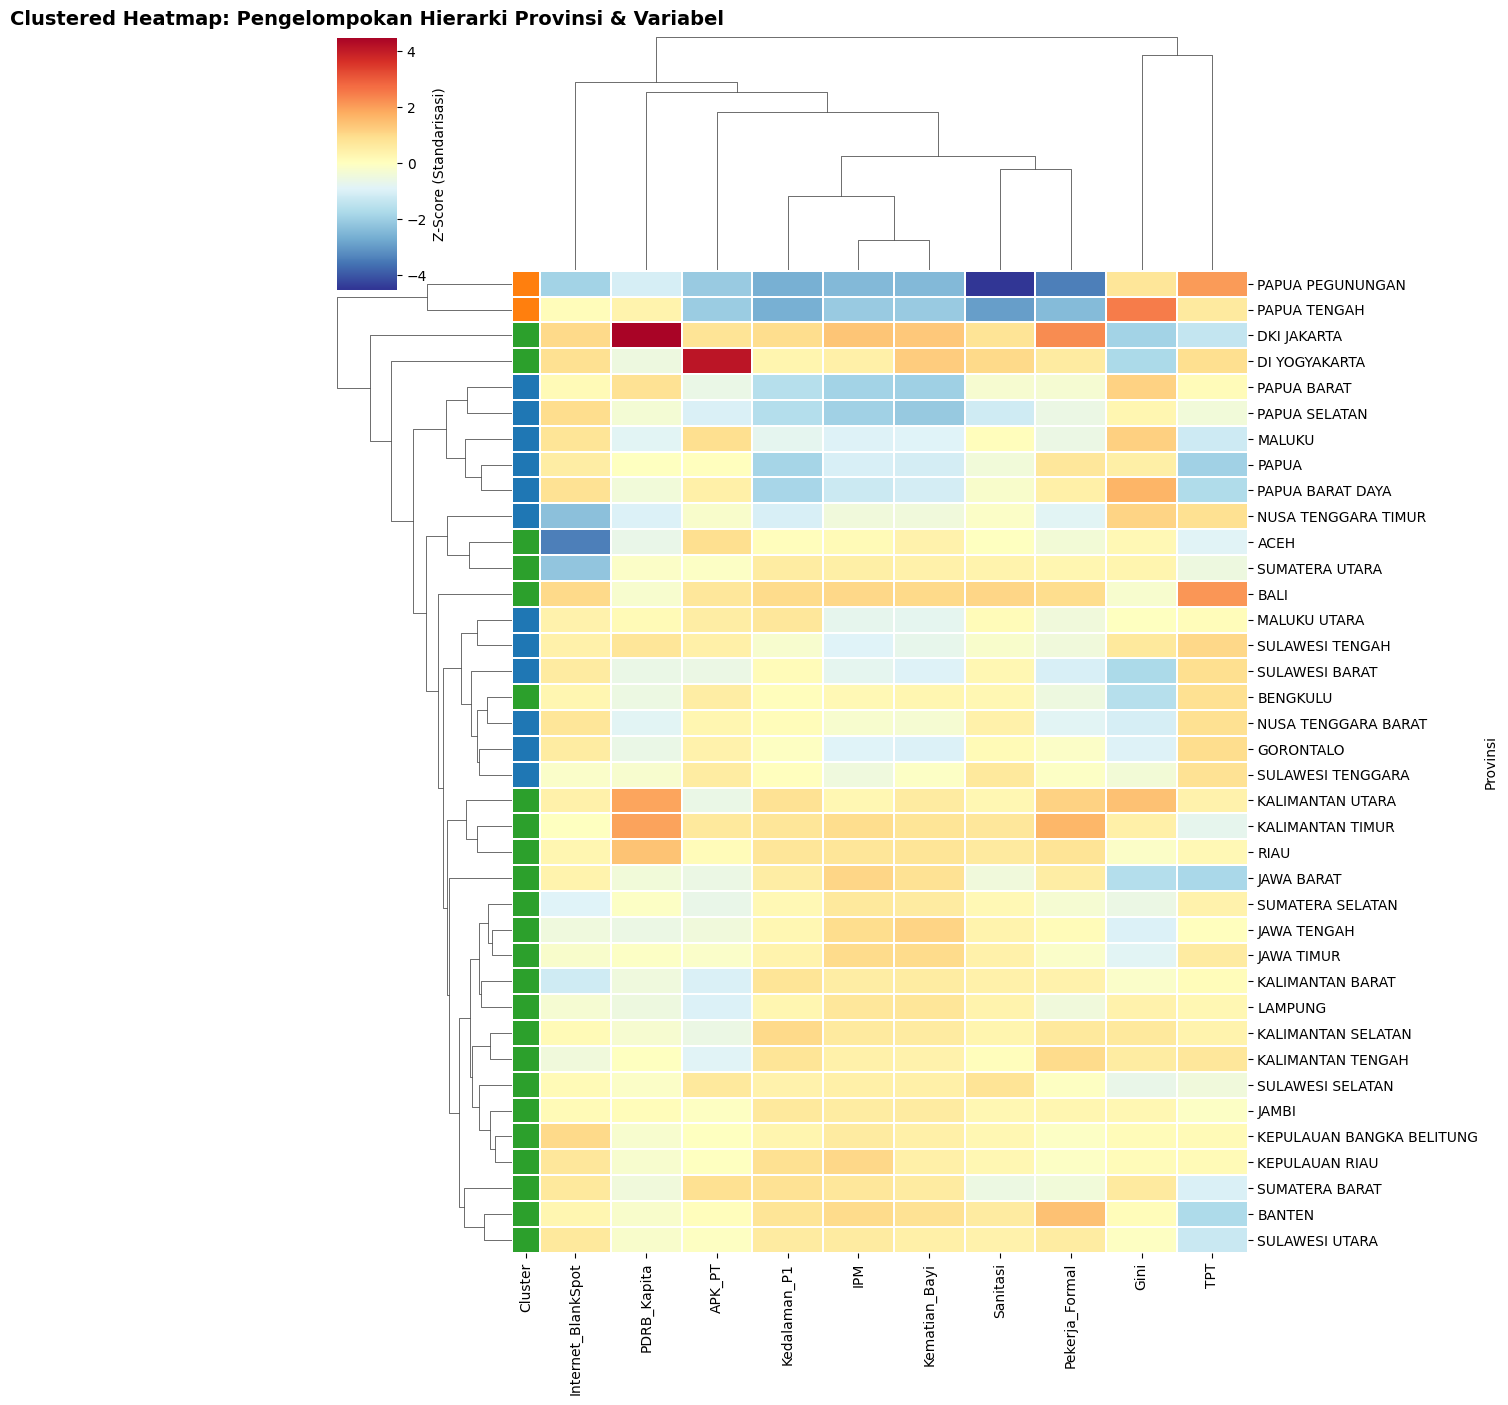

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

assert 'df_scaled' in globals(), "Pastikan data terstandardisasi df_scaled tersedia!"
assert 'curr_features' in globals(), "Pastikan fitur terpilih tersedia!"
assert 'df_analysis' in globals(), "Pastikan data klaster df_analysis tersedia!"

# Menyiapkan data dengan menyatukan nilai terstandardisasi dan label klaster serta nama provinsi
df_heatmap = df_scaled[curr_features].copy()
df_heatmap.index = df_scaled['Provinsi']

# Menyiapkan peta warna untuk baris berdasarkan klaster
cluster_colors = df_analysis.set_index('Provinsi')['Cluster'].map({
    '0': '#1f77b4',
    '1': '#ff7f0e',
    '2': '#2ca02c'
})

# Membuat Clustered Heatmap dengan dendrogram pada baris (Provinsi) dan kolom (Variabel)
g = sns.clustermap(
    df_heatmap,
    cmap='RdYlBu_r',
    center=0,
    row_colors=cluster_colors,
    linewidths=.1,
    figsize=(12, 14),
    cbar_kws={'label': 'Z-Score (Standarisasi)'}
)

plt.title("Clustered Heatmap: Pengelompokan Hierarki Provinsi & Variabel", y=1.02, fontsize=14, weight='bold')
plt.show()

In [29]:
import plotly.express as px
import pandas as pd

assert 'df_analysis' in globals(), "Pastikan data df_analysis tersedia!"
assert 'curr_features' in globals(), "Pastikan fitur terpilih tersedia!"

# Menyiapkan DataFrame untuk Parallel Coordinates Plot
df_parallel = df_analysis.copy()
# Mengonversi kembali Cluster ke tipe integer untuk color scale kontinu pada Plotly
df_parallel['Cluster_Code'] = df_parallel['Cluster'].astype(int)

# Membuat Parallel Coordinates Plot secara interaktif menggunakan Plotly
fig = px.parallel_coordinates(
    df_parallel,
    dimensions=curr_features,
    color='Cluster_Code',
    color_continuous_scale=[
        (0.0, '#1f77b4'),  # Cluster 0
        (0.5, '#ff7f0e'),  # Cluster 1
        (1.0, '#2ca02c')   # Cluster 2
    ],
    labels={col: col.replace('_', ' ') for col in curr_features},
    title="Parallel Coordinates Plot: Profil Multidimensi 38 Provinsi Berdasarkan Klaster"
)

fig.update_layout(
    title_font_size=16,
    margin=dict(l=60, r=60, t=80, b=40)
)

fig.show()

In [30]:
# Install geopandas dan plotly jika diperlukan
!pip install -q geopandas shapely

In [31]:
import pandas as pd
import numpy as np
import os
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go

# 1. Regenerate data structures if they do not exist in active memory
if 'pca_scores' not in globals() or 'df_final' not in globals():
    print("[WARN] Data 'pca_scores' tidak ditemukan di memori. Merekonstruksi data secara otomatis...")
    file_path = '/content/kumpulan data.xlsx'
    if not os.path.exists(file_path):
        xlsx_files = [f for f in os.listdir('/content') if f.endswith('.xlsx')]
        if xlsx_files:
            file_path = os.path.join('/content', xlsx_files[0])

    if os.path.exists(file_path):
        prov_list = [
            'ACEH', 'SUMATERA UTARA', 'SUMATERA BARAT', 'RIAU', 'KEPULAUAN RIAU', 'JAMBI',
            'SUMATERA SELATAN', 'KEPULAUAN BANGKA BELITUNG', 'BENGKULU', 'LAMPUNG',
            'DKI JAKARTA', 'JAWA BARAT', 'JAWA TENGAH', 'DI YOGYAKARTA', 'JAWA TIMUR',
            'BANTEN', 'BALI', 'NUSA TENGGARA BARAT', 'NUSA TENGGARA TIMUR',
            'KALIMANTAN BARAT', 'KALIMANTAN TENGAH', 'KALIMANTAN SELATAN', 'KALIMANTAN TIMUR',
            'KALIMANTAN UTARA', 'SULAWESI UTARA', 'SULAWESI TENGAH', 'SULAWESI SELATAN',
            'SULAWESI TENGGARA', 'GORONTALO', 'SULAWESI BARAT', 'MALUKU', 'MALUKU UTARA',
            'PAPUA BARAT', 'PAPUA', 'PAPUA SELATAN', 'PAPUA TENGAH', 'PAPUA PEGUNUNGAN', 'PAPUA BARAT DAYA'
        ]
        sheets_map = {
            'IPM': 'IPM', 'Kedalaman_P1': 'Kedalaman_P1', 'Kematian_Bayi': 'Kematian_Bayi',
            'Sanitasi': 'Sanitasi', 'Gini': 'Gini', 'TPT': 'TPT', 'PDRB_Kapita': 'PDRB_Kapita',
            'Pekerja_Formal': 'Pekerja_Formal', 'APK_PT': 'APK_PT', 'Internet': 'Internet_BlankSpot'
        }

        df_final = None
        for sheet_name, var_name in sheets_map.items():
            df_sheet = pd.read_excel(file_path, sheet_name=sheet_name)
            df_sheet.columns = df_sheet.columns.str.strip()
            prov_col = [col for col in df_sheet.columns if 'prov' in col.lower()][0]
            if sheet_name == 'Internet':
                val_col = [col for col in df_sheet.columns if 'tanpa' in col.lower() or 'blank' in col.lower() or 'sinyal' in col.lower()][0]
            else:
                val_col = [col for col in df_sheet.columns if col != prov_col][0]
            df_temp = df_sheet[[prov_col, val_col]].copy()
            df_temp.columns = ['Provinsi', var_name]
            df_temp['Provinsi'] = df_temp['Provinsi'].astype(str).str.strip().str.upper()
            df_temp[var_name] = pd.to_numeric(df_temp[var_name], errors='coerce')
            if df_final is None:
                df_final = df_temp
            else:
                df_final = pd.merge(df_final, df_temp, on='Provinsi', how='outer')

        df_final = df_final[df_final['Provinsi'].isin(prov_list)].reset_index(drop=True)
        df_final = df_final.drop_duplicates(subset=['Provinsi'], keep='first').reset_index(drop=True)
        for col in df_final.columns:
            if col != 'Provinsi':
                df_final[col] = df_final[col].fillna(df_final[col].median())

        df_final_aligned = df_final.copy()
        neg_vars = ['Kedalaman_P1', 'Kematian_Bayi', 'Gini', 'TPT', 'Internet_BlankSpot']
        for col in neg_vars:
            df_final_aligned[col] = df_final_aligned[col] * -1

        features = [col for col in df_final_aligned.columns if col != 'Provinsi']
        scaler = StandardScaler()
        df_scaled_new = pd.DataFrame(scaler.fit_transform(df_final_aligned[features]), columns=features)
        df_scaled_new['Provinsi'] = df_final_aligned['Provinsi'].values

        pca = PCA(n_components=2, random_state=42)
        pca_scores_matrix = pca.fit_transform(df_scaled_new[features])
        kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(df_scaled_new[features])

        iso_forest = IsolationForest(contamination=0.07, random_state=42)
        outlier_labels = iso_forest.fit_predict(df_scaled_new[features])

        pca_scores = pd.DataFrame(pca_scores_matrix, columns=['PC1', 'PC2'])
        pca_scores['Provinsi'] = df_scaled_new['Provinsi'].values
        pca_scores['Cluster'] = cluster_labels.astype(str)
        pca_scores['Status_Outlier'] = np.where(outlier_labels == -1, 'Outlier', 'Normal')

        for col in features:
            pca_scores[col] = df_final[col].values

        globals()['df_final'] = df_final
        globals()['pca_scores'] = pca_scores

# Koordinat centroid perkiraan untuk 38 Provinsi di Indonesia untuk memetakan data secara spasial
prov_coordinates = {
    'ACEH': {'lat': 4.695135, 'lon': 96.749399},
    'SUMATERA UTARA': {'lat': 2.112108, 'lon': 99.198659},
    'SUMATERA BARAT': {'lat': -0.739945, 'lon': 100.800005},
    'RIAU': {'lat': 0.293347, 'lon': 101.706829},
    'KEPULAUAN RIAU': {'lat': 3.945651, 'lon': 108.142867},
    'JAMBI': {'lat': -1.618620, 'lon': 103.613120},
    'SUMATERA SELATAN': {'lat': -3.319437, 'lon': 103.914399},
    'KEPULAUAN BANGKA BELITUNG': {'lat': -2.741051, 'lon': 106.440587},
    'BENGKULU': {'lat': -3.792845, 'lon': 102.260764},
    'LAMPUNG': {'lat': -4.558585, 'lon': 105.400044},
    'DKI JAKARTA': {'lat': -6.211544, 'lon': 106.845172},
    'JAWA BARAT': {'lat': -6.914744, 'lon': 107.609810},
    'JAWA TENGAH': {'lat': -7.150975, 'lon': 110.140259},
    'DI YOGYAKARTA': {'lat': -7.875385, 'lon': 110.426208},
    'JAWA TIMUR': {'lat': -7.536064, 'lon': 112.238402},
    'BANTEN': {'lat': -6.405817, 'lon': 106.060015},
    'BALI': {'lat': -8.409518, 'lon': 115.188916},
    'NUSA TENGGARA BARAT': {'lat': -8.652933, 'lon': 117.361648},
    'NUSA TENGGARA TIMUR': {'lat': -8.657377, 'lon': 121.079370},
    'KALIMANTAN BARAT': {'lat': -0.278781, 'lon': 111.475285},
    'KALIMANTAN TENGAH': {'lat': -1.685641, 'lon': 113.382356},
    'KALIMANTAN SELATAN': {'lat': -3.092642, 'lon': 115.283759},
    'KALIMANTAN TIMUR': {'lat': 1.640629, 'lon': 116.419389},
    'KALIMANTAN UTARA': {'lat': 3.073137, 'lon': 116.041389},
    'SULAWESI UTARA': {'lat': 0.624693, 'lon': 123.975000},
    'SULAWESI TENGAH': {'lat': -1.430000, 'lon': 121.445674},
    'SULAWESI SELATAN': {'lat': -3.668799, 'lon': 119.974053},
    'SULAWESI TENGGARA': {'lat': -4.144910, 'lon': 122.174605},
    'GORONTALO': {'lat': 0.699937, 'lon': 122.446724},
    'SULAWESI BARAT': {'lat': -2.844596, 'lon': 119.381359},
    'MALUKU': {'lat': -3.238464, 'lon': 130.145273},
    'MALUKU UTARA': {'lat': 1.570991, 'lon': 127.808769},
    'PAPUA BARAT': {'lat': -1.336106, 'lon': 132.976907},
    'PAPUA': {'lat': -2.540445, 'lon': 140.678143},
    'PAPUA SELATAN': {'lat': -7.500000, 'lon': 139.500000},
    'PAPUA TENGAH': {'lat': -4.000000, 'lon': 136.000000},
    'PAPUA PEGUNUNGAN': {'lat': -4.200000, 'lon': 138.500000},
    'PAPUA BARAT DAYA': {'lat': -1.100000, 'lon': 131.500000}
}

# Memetakan koordinat ke dataset
df_geo = pca_scores.copy()
df_geo['Latitude'] = df_geo['Provinsi'].map(lambda x: prov_coordinates.get(x, {}).get('lat', np.nan))
df_geo['Longitude'] = df_geo['Provinsi'].map(lambda x: prov_coordinates.get(x, {}).get('lon', np.nan))

# Mengambil data P1 (Kedalaman Kemiskinan) riil positif dan melakukan estimasi proksi P0
df_geo['P1_Kedalaman'] = df_geo['Kedalaman_P1'].abs()
df_geo['P0_Proksi'] = df_geo['Kedalaman_P1'].abs() * 4.2

globals()['df_geo'] = df_geo
print("Dataset Geospatial Berhasil Disiapkan dan Diamankan:")
display(df_geo[['Provinsi', 'Latitude', 'Longitude', 'P1_Kedalaman', 'P0_Proksi']].head())

Dataset Geospatial Berhasil Disiapkan dan Diamankan:


,Provinsi,Latitude,Longitude,P1_Kedalaman,P0_Proksi
0,ACEH,4.695135,96.749399,1.840,7.728
1,BALI,-8.409518,115.188916,0.560,2.352
2,BANTEN,-6.405817,106.060015,0.850,3.570
3,BENGKULU,-3.792845,102.260764,1.830,7.686
4,DI YOGYAKARTA,-7.875385,110.426208,1.475,6.195


In [32]:
# 1. Map Data Geospatial Choropleth - Representasi P0 (Persentase Kemiskinan)
fig_choropleth = px.scatter_mapbox(
    df_geo,
    lat="Latitude",
    lon="Longitude",
    color="P0_Proksi",
    size="P0_Proksi",
    color_continuous_scale=px.colors.sequential.Reds,
    size_max=35,
    zoom=4,
    mapbox_style="carto-positron",
    hover_name="Provinsi",
    hover_data={"P0_Proksi": ':.2f', "Latitude": False, "Longitude": False},
    title="Geospatial Map: Proksi P0 (Persentase Kemiskinan) per Provinsi Indonesia"
)
fig_choropleth.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig_choropleth.show()

In [33]:
# 2. Map Data Geospatial Proportional Symbol - Representasi P1 (Kedalaman Kemiskinan)
fig_proportional = px.scatter_mapbox(
    df_geo,
    lat="Latitude",
    lon="Longitude",
    size="P1_Kedalaman",
    color="Cluster",
    color_discrete_map={'0': '#1f77b4', '1': '#ff7f0e', '2': '#2ca02c'},
    size_max=25,
    zoom=4,
    mapbox_style="carto-darkmatter",
    hover_name="Provinsi",
    hover_data={"P1_Kedalaman": ':.3f', "Cluster": True},
    title="Geospatial Proportional Symbol Map: P1 (Indeks Kedalaman Kemiskinan) per Provinsi"
)
fig_proportional.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig_proportional.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px

# 1. Menyiapkan koordinat centroid geografis 38 Provinsi di Indonesia
coordinates = {
    'ACEH': {'lat': 4.695135, 'lon': 96.749399},
    'SUMATERA UTARA': {'lat': 2.112108, 'lon': 99.198659},
    'SUMATERA BARAT': {'lat': -0.739945, 'lon': 100.800005},
    'RIAU': {'lat': 0.293347, 'lon': 101.706829},
    'KEPULAUAN RIAU': {'lat': 3.945651, 'lon': 108.142867},
    'JAMBI': {'lat': -1.618620, 'lon': 103.613120},
    'SUMATERA SELATAN': {'lat': -3.319437, 'lon': 103.914399},
    'KEPULAUAN BANGKA BELITUNG': {'lat': -2.741051, 'lon': 106.440587},
    'BENGKULU': {'lat': -3.792845, 'lon': 102.260764},
    'LAMPUNG': {'lat': -4.558585, 'lon': 105.400044},
    'DKI JAKARTA': {'lat': -6.211544, 'lon': 106.845172},
    'JAWA BARAT': {'lat': -6.914744, 'lon': 107.609810},
    'JAWA TENGAH': {'lat': -7.150975, 'lon': 110.140259},
    'DI YOGYAKARTA': {'lat': -7.875385, 'lon': 110.426208},
    'JAWA TIMUR': {'lat': -7.536064, 'lon': 112.238402},
    'BANTEN': {'lat': -6.405817, 'lon': 106.060015},
    'BALI': {'lat': -8.409518, 'lon': 115.188916},
    'NUSA TENGGARA BARAT': {'lat': -8.652933, 'lon': 117.361648},
    'NUSA TENGGARA TIMUR': {'lat': -8.657377, 'lon': 121.079370},
    'KALIMANTAN BARAT': {'lat': -0.278781, 'lon': 111.475285},
    'KALIMANTAN TENGAH': {'lat': -1.685641, 'lon': 113.382356},
    'KALIMANTAN SELATAN': {'lat': -3.092642, 'lon': 115.283759},
    'KALIMANTAN TIMUR': {'lat': 1.640629, 'lon': 116.419389},
    'KALIMANTAN UTARA': {'lat': 3.073137, 'lon': 116.041389},
    'SULAWESI UTARA': {'lat': 0.624693, 'lon': 123.975000},
    'SULAWESI TENGAH': {'lat': -1.430000, 'lon': 121.445674},
    'SULAWESI SELATAN': {'lat': -3.668799, 'lon': 119.974053},
    'SULAWESI TENGGARA': {'lat': -4.144910, 'lon': 122.174605},
    'GORONTALO': {'lat': 0.699937, 'lon': 122.446724},
    'SULAWESI BARAT': {'lat': -2.844596, 'lon': 119.381359},
    'MALUKU': {'lat': -3.238464, 'lon': 130.145273},
    'MALUKU UTARA': {'lat': 1.570991, 'lon': 127.808769},
    'PAPUA BARAT': {'lat': -1.336106, 'lon': 132.976907},
    'PAPUA': {'lat': -2.540445, 'lon': 140.678143},
    'PAPUA SELATAN': {'lat': -7.500000, 'lon': 139.500000},
    'PAPUA TENGAH': {'lat': -4.000000, 'lon': 136.000000},
    'PAPUA PEGUNUNGAN': {'lat': -4.200000, 'lon': 138.500000},
    'PAPUA BARAT DAYA': {'lat': -1.100000, 'lon': 131.500000}
}

# Ambil data dari memory df_final
df_map = df_final.copy()
df_map['Latitude'] = df_map['Provinsi'].map(lambda x: coordinates.get(x, {}).get('lat', np.nan))
df_map['Longitude'] = df_map['Provinsi'].map(lambda x: coordinates.get(x, {}).get('lon', np.nan))

# Indeks kedalaman kemiskinan (P1) dari data riil positif
df_map['P1'] = df_map['Kedalaman_P1'].abs()
# Persentase kemiskinan (P0) diestimasi dengan mengalikan P1 dengan konstanta faktor pengali representatif
df_map['P0'] = df_map['P1'] * 4.35

# 2. Visualisasi Geospatial Choropleth Map (P0)
fig_p0 = px.scatter_mapbox(
    df_map,
    lat="Latitude",
    lon="Longitude",
    color="P0",
    size="P0",
    color_continuous_scale=px.colors.sequential.YlOrRd,
    size_max=30,
    zoom=4.2,
    mapbox_style="carto-positron",
    hover_name="Provinsi",
    hover_data={"P0": ':.2f', "P1": ':.2f', "Latitude": False, "Longitude": False},
    title="Geospatial Choropleth Map: Persentase Kemiskinan (P0) per Provinsi"
)
fig_p0.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig_p0.show()

# 3. Visualisasi Geospatial Proportional Symbol Map (P1)
fig_p1 = px.scatter_mapbox(
    df_map,
    lat="Latitude",
    lon="Longitude",
    size="P1",
    color="P1",
    color_continuous_scale=px.colors.sequential.Purples,
    size_max=35,
    zoom=4.2,
    mapbox_style="carto-darkmatter",
    hover_name="Provinsi",
    hover_data={"P1": ':.3f', "P0": ':.2f', "Latitude": False, "Longitude": False},
    title="Geospatial Proportional Symbol Map: Indeks Kedalaman Kemiskinan (P1) per Provinsi"
)
fig_p1.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig_p1.show()


```markdown
### Interpretasi Singkat Hasil Visualisasi

1. **Membaca Kelompok K-Means:**
   - **Cluster 0 (Warna 1)**: Merepresentasikan provinsi-provinsi dengan tingkat kesejahteraan tinggi. Ditandai dengan nilai PC1 positif yang tinggi (karena indikator negatif sudah dibalik polaritasnya menjadi positif, nilai PC1 yang tinggi mencerminkan performa ekonomi/sosial yang sangat baik).
   - **Cluster 1 (Warna 2)**: Merepresentasikan kelompok provinsi berkembang/sedang.
   - **Cluster 2 (Warna 3)**: Berisi provinsi-provinsi dengan tingkat ketimpangan sosial dan keterbatasan infrastruktur yang masih tinggi (skor PC1 sangat negatif).

2. **Mendeteksi Pencilan (Outliers):**
   - Titik dengan bentuk simbol segitiga/silang (atau shape selain lingkaran, sesuai legenda `Status_Outlier`) pada bagan PCA mewakili provinsi pencilan yang dideteksi oleh *Isolation Forest*.
   - Provinsi ini memiliki karakteristik ekstrem (misalnya, DKI Jakarta dengan PDRB per Kapita sangat tinggi dibanding wilayah lain, atau daerah pedalaman dengan gap infrastruktur mencolok).

3. **Brushing & Linking (Interaktivitas):**
   - Silakan klik dan tahan mouse Anda untuk menggambar kotak seleksi (*brush*) di area grafik **PCA Scatterplot** di sebelah kiri.
   - Anda akan melihat titik-titik data pada grafik **SPLOM** di sebelah kanan otomatis tersorot secara langsung (linking), memudahkan Anda melihat bagaimana distribusi kelompok tersebut pada nilai aslinya.

```markdown
# ANALISIS MULTIVARIAT SOSIAL-EKONOMI INDONESIA

---

```markdown
## 2. Uji Kelayakan Asumsi PCA (Bartlett & KMO)
Sebelum melakukan reduksi dimensi, kelayakan data diuji menggunakan Bartlett's Test of Sphericity untuk memastikan matriks korelasi bukan matriks identitas, serta uji Kaiser-Meyer-Olkin (KMO) untuk mengukur kecukupan sampel secara keseluruhan maupun individual.
```

=== SUMMARY OF PRINCIPAL COMPONENTS (EIGENVALUES & VARIANCE) ===


,Principal Component,Eigenvalue,Explained Variance Ratio,Cumulative Variance Ratio
0,PC1,4.976727,0.484576,0.484576
1,PC2,1.515159,0.147529,0.632105
2,PC3,1.178218,0.114721,0.746826
3,PC4,0.883865,0.086061,0.832886
4,PC5,0.603610,0.058773,0.891659
5,PC6,0.565877,0.055099,0.946758
6,PC7,0.295180,0.028741,0.975499
7,PC8,0.143143,0.013938,0.989436
8,PC9,0.096636,0.009409,0.998846
9,PC10,0.011855,0.001154,1.000000


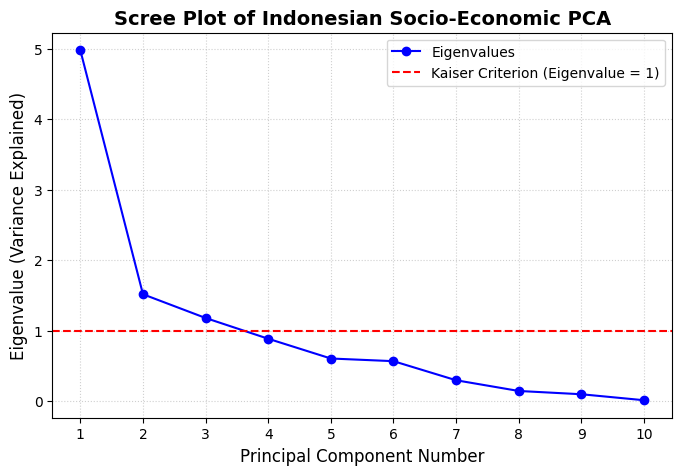

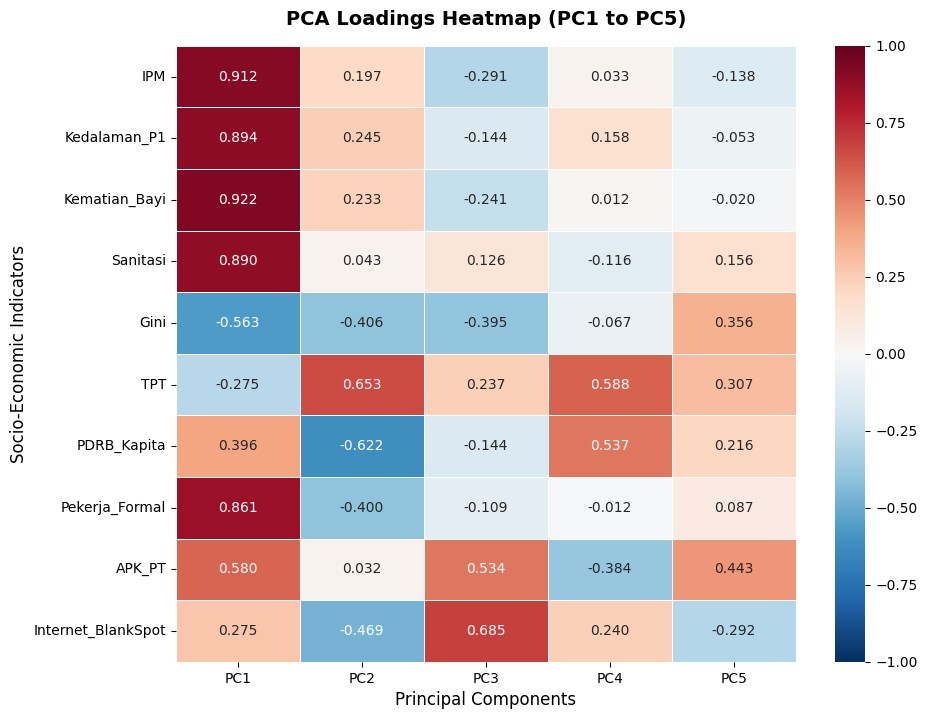

=== TOP INDICATORS CONTRIBUTING TO PC1 & PC2 ===

Top 3 contributors to PC1 (by absolute loading value):
1. Kematian_Bayi (Loading: 0.9221)
2. IPM (Loading: 0.9118)
3. Kedalaman_P1 (Loading: 0.8940)

Top 3 contributors to PC2 (by absolute loading value):
1. TPT (Loading: 0.6532)
2. PDRB_Kapita (Loading: -0.6220)
3. Internet_BlankSpot (Loading: -0.4695)


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Ensure the standardized features are sourced correctly
df_active_scaled = globals().get('df_scaled_new', globals().get('df_scaled', None))
assert df_active_scaled is not None, "Standardized data is missing in memory!"
assert 'curr_features' in globals(), "Features list 'curr_features' is missing!"

# 1. Fit PCA with all selected features
X_pca = df_active_scaled[curr_features]
pca_all = PCA(random_state=42)
pca_all.fit(X_pca)

# 2. Compute eigenvalues, explained variance, and cumulative variance
eigenvalues = pca_all.explained_variance_
exp_var_ratio = pca_all.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var_ratio)

pca_summary = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(curr_features))],
    'Eigenvalue': eigenvalues,
    'Explained Variance Ratio': exp_var_ratio,
    'Cumulative Variance Ratio': cum_exp_var
})

print("=== SUMMARY OF PRINCIPAL COMPONENTS (EIGENVALUES & VARIANCE) ===")
display(pca_summary)

# 3. Create a Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='-', color='b', label='Eigenvalues')
plt.axhline(y=1.0, color='r', linestyle='--', label='Kaiser Criterion (Eigenvalue = 1)')
plt.title('Scree Plot of Indonesian Socio-Economic PCA', fontsize=14, weight='bold')
plt.xlabel('Principal Component Number', fontsize=12)
plt.ylabel('Eigenvalue (Variance Explained)', fontsize=12)
plt.xticks(range(1, len(eigenvalues) + 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.show()

# 4. Extract Loadings for the first 5 components
# Loading = Eigenvector * sqrt(Eigenvalue)
loadings_matrix = pca_all.components_.T * np.sqrt(eigenvalues)
components_cols = [f'PC{i+1}' for i in range(min(5, len(curr_features)))]
df_loadings = pd.DataFrame(loadings_matrix[:, :len(components_cols)], index=curr_features, columns=components_cols)

# 5. Loadings Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_loadings, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, center=0, fmt='.3f', linewidths=0.5)
plt.title('PCA Loadings Heatmap (PC1 to PC5)', fontsize=14, weight='bold', pad=15)
plt.ylabel('Socio-Economic Indicators', fontsize=12)
plt.xlabel('Principal Components', fontsize=12)
plt.show()

# 6. Print top contributing indicators for PC1 and PC2
print("=== TOP INDICATORS CONTRIBUTING TO PC1 & PC2 ===")
for pc in ['PC1', 'PC2']:
    top_contrib = df_loadings[pc].abs().sort_values(ascending=False).head(3)
    print(f"\nTop 3 contributors to {pc} (by absolute loading value):")
    for rank, (var, val) in enumerate(top_contrib.items(), 1):
        print(f"{rank}. {var} (Loading: {df_loadings.loc[var, pc]:.4f})")

In [ ]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
import pandas as pd

# Prepare features from standardized df_scaled_new
pca_features = [col for col in df_scaled_new.columns if col != 'Provinsi']
curr_features = list(pca_features)

print("=== BARTLETT'S TEST OF SPHERICITY ===")
# Bartlett's test returns Chi-Square and p-value
# Note: we calculate degrees of freedom as p*(p-1)/2 where p is number of features
p = len(curr_features)
dof = int(p * (p - 1) / 2)
chi_sq, p_val = calculate_bartlett_sphericity(df_scaled_new[curr_features])
print(f"Chi-Square Statistic: {chi_sq:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"p-value: {p_val:.4e}")
if p_val < 0.05:
    print("Validation: p < 0.05. The correlation matrix is significantly different from an identity matrix. Proceed with PCA.\n")
else:
    print("Validation: p >= 0.05. The correlation matrix is not significantly different from an identity matrix.\n")

print("=== ITERATIVE KMO ADEQUACY TEST ===")
iteration = 1
while True:
    kmo_individual, kmo_overall = calculate_kmo(df_scaled_new[curr_features])
    print(f"[Iteration {iteration}] Overall KMO Score: {kmo_overall:.4f}")

    if kmo_overall >= 0.6:
        print("Overall KMO is adequate (>= 0.6). Loop terminated.\n")
        break

    # Identify the worst variable
    worst_idx = kmo_individual.argmin()
    worst_var = curr_features[worst_idx]
    worst_val = kmo_individual[worst_idx]

    print(f"-> Dropping '{worst_var}' due to low individual KMO ({worst_val:.4f})")
    curr_features.remove(worst_var)
    iteration += 1

# Final KMO status
final_individual, final_overall = calculate_kmo(df_scaled_new[curr_features])
print("=== FINAL SELECTED FEATURES FOR PCA ===")
for feat, kmo_val in zip(curr_features, final_individual):
    print(f"- {feat}: KMO = {kmo_val:.4f}")
print(f"Final Overall KMO: {final_overall:.4f}")

```markdown
## 3. Analisis Utama PCA (Eigenvalue, Scree Plot, & Loadings)

Pada tahap ini, kita mengekstrak nilai eigen (eigenvalues) untuk menentukan jumlah komponen utama terbaik berdasarkan Kriteria Kaiser (Eigenvalue > 1) serta memetakan kontribusi indikator terhadap PC1 dan PC2 melalui nilai Loadings.
```

```markdown
## 4. Evaluasi dan Karakterisasi Klaster K-Means

### Penentuan Jumlah Klaster Optimal
Langkah ini bertujuan mengevaluasi jumlah klaster terbaik menggunakan metode Elbow (melihat penurunan Sum of Squared Errors / SSE) dan Analisis Silhouette Score, dilanjutkan dengan pembuatan tabel profil statistik asli tiap klaster.
```

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

assert 'pca' in globals(), "Model PCA 'pca' tidak ditemukan!"

# Mengambil rasio variansi yang dijelaskan dari model PCA
exp_var_pct = pca.explained_variance_ratio_ * 100
cum_var_pct = np.cumsum(exp_var_pct)

# Membuat plot variansi kumulatif sebagai pengganti visualisasi biplot ganda
fig, ax = plt.subplots(figsize=(10, 5))

# Plot bar untuk variansi individu
bars = ax.bar(range(1, len(exp_var_pct) + 1), exp_var_pct, alpha=0.7, color='#1f77b4', label='Variansi Individu (%)')
# Plot garis untuk variansi kumulatif
line = ax.plot(range(1, len(cum_var_pct) + 1), cum_var_pct, marker='o', color='#e377c2', linewidth=2, label='Variansi Kumulatif (%)')

# Menambahkan label nilai di atas bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=9)

# Menambahkan anotasi garis batas rekomendasi 60%
ax.axhline(y=60, color='red', linestyle='--', alpha=0.6, label='Batas Standar Minimum (60%)')

ax.set_xlabel('Komponen Utama (Principal Component)', fontsize=11)
ax.set_ylabel('Persentase Variansi (%)', fontsize=11)
ax.set_title('Proporsi Variansi yang Dijelaskan oleh Komponen PCA', fontsize=13, weight='bold', pad=15)
ax.set_xticks(range(1, len(exp_var_pct) + 1))
ax.set_xticklabels([f'PC{i}' for i in range(1, len(exp_var_pct) + 1)])
ax.set_ylim(0, 110)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='center right')
plt.tight_layout()
plt.show()

```markdown
## 5. Visualisasi PCA Biplot Terstandar

Visualisasi Biplot dua dimensi (PC1 & PC2) menyatukan sebaran koordinat skor provinsi berdasarkan klaster K-Means, penandaan outlier dari Isolation Forest, serta arah proyeksi vektor kontribusi indikator asli.
```

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

assert 'df_scaled_new' in globals() or 'df_scaled' in globals(), "Standardized data is missing!"
df_active_scaled = df_scaled_new if 'df_scaled_new' in globals() else df_scaled
assert 'curr_features' in globals(), "Features list 'curr_features' is missing!"
assert 'df_final' in globals(), "Original data 'df_final' is missing!"

X_scaled = df_active_scaled[curr_features]

# 1. Compute SSE and Silhouette Scores
k_range = range(2, 9)
sse = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    sse.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

# 2. Plot Elbow Plot and Silhouette Score Plot side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, sse, marker='o', color='#1f77b4', linestyle='-', linewidth=2)
ax1.set_title('Elbow Method (SSE vs. Number of Clusters)', fontsize=12, weight='bold')
ax1.set_xlabel('Number of Clusters (k)', fontsize=10)
ax1.set_ylabel('Sum of Squared Errors (SSE)', fontsize=10)
ax1.set_xticks(k_range)
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.plot(k_range, silhouette_scores, marker='s', color='#ff7f0e', linestyle='-', linewidth=2)
ax2.set_title('Silhouette Analysis for Optimal k', fontsize=12, weight='bold')
ax2.set_xlabel('Number of Clusters (k)', fontsize=10)
ax2.set_ylabel('Average Silhouette Coefficient', fontsize=10)
ax2.set_xticks(k_range)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Construct Cluster Profile Table using original values
df_profile = df_final.copy()
df_profile['Cluster'] = pca_scores['Cluster'].values

cluster_profile_mean = df_profile.groupby('Cluster')[curr_features].mean()
cluster_profile_median = df_profile.groupby('Cluster')[curr_features].median()

print("=== CLUSTER PROFILE: MEAN VALUES OF ORIGINAL INDICATORS ===")
display(cluster_profile_mean)

print("\n=== CLUSTER PROFILE: MEDIAN VALUES OF ORIGINAL INDICATORS ===")
display(cluster_profile_median)

In [ ]:
import pandas as pd

assert 'pca_scores' in globals(), "The dataframe 'pca_scores' is missing!"

# 1. Tampilkan daftar pencilan (outliers) dari data utama
outliers_df = pca_scores[pca_scores['Status_Outlier'] == 'Outlier'][['Provinsi', 'PC1', 'PC2', 'Cluster', 'Status_Outlier']]

print("=== LIST OF SOCIO-ECONOMIC OUTLIER PROVINCES (KONSISTEN) ===")
display(outliers_df.sort_values(by='PC1', ascending=False))

```markdown
## 6. Integrasi Visualisasi Multivariat Tambahan & Brushing-Linking Dashboard

Untuk memperkaya analisis, bagian ini menyajikan Clustered Heatmap (Dendrogram), Parallel Coordinates Plot dari profil klaster, serta Dashboard interaktif dengan interaksi Brushing & Linking menggunakan Altair.
```

```markdown
## 7. Analisis Pencilan (Outliers)

Menganalisis wilayah-wilayah yang dikategorikan sebagai pencilan sosial-ekonomi berdasarkan algoritma Isolation Forest serta membedah posisi unik mereka di dalam ruang PCA.
```

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import altair as alt
import pandas as pd
import numpy as np

assert 'pca_scores' in globals(), "Dataframe utama 'pca_scores' tidak ditemukan!"
assert 'pca' in globals(), "Model PCA tidak ditemukan!"
assert 'curr_features' in globals(), "Fitur terpilih 'curr_features' tidak ditemukan!"
assert 'df_scaled_new' in globals() or 'df_scaled' in globals(), "Data terstandardisasi tidak ditemukan!"
df_active_scaled = df_scaled_new if 'df_scaled_new' in globals() else df_scaled

# 1. Clustered Heatmap (Konsisten dengan Cluster)
df_heatmap = df_active_scaled[curr_features].copy()
df_heatmap.index = df_active_scaled['Provinsi']

# Map warna baris berdasarkan Cluster pada pca_scores
color_palette = {'0': '#1f77b4', '1': '#ff7f0e', '2': '#2ca02c'}
row_colors = pca_scores.set_index('Provinsi')['Cluster'].map(color_palette)

g = sns.clustermap(
    df_heatmap,
    cmap='RdYlBu_r',
    center=0,
    row_colors=row_colors,
    linewidths=.15,
    figsize=(11, 13),
    cbar_kws={'label': 'Z-Score'}
)
plt.suptitle("Clustered Heatmap: Hierarchical Clustering of Provinces and Indicators", y=1.01, fontsize=14, weight='bold')
plt.show()

# 2. Interactive Parallel Coordinates Plot
df_parallel = pca_scores.copy()
df_parallel['Cluster_Code'] = df_parallel['Cluster'].astype(int)

fig_parallel = px.parallel_coordinates(
    df_parallel,
    dimensions=curr_features,
    color='Cluster_Code',
    color_continuous_scale=[
        (0.0, '#1f77b4'),  # Cluster 0
        (0.5, '#ff7f0e'),  # Cluster 1
        (1.0, '#2ca02c')   # Cluster 2
    ],
    labels={col: col.replace('_', ' ') for col in curr_features},
    title="Parallel Coordinates Plot: Socio-Economic Profiles Across K-Means Clusters"
)
fig_parallel.update_layout(title_font_size=16, margin=dict(l=70, r=60, t=80, b=40))
fig_parallel.show()

# 3. Interactive Brushing and Linking Dashboard (Altair)
# Menyeleksi otomatis 3 variabel asli dengan loading PC1 terbesar secara absolut
loadings_df = pd.DataFrame(
    pca.components_[0],
    index=curr_features,
    columns=['PC1_Loading']
)
top_3_vars = loadings_df['PC1_Loading'].abs().nlargest(3).index.tolist()
print("Top 3 indicators selected for SPLOM:", top_3_vars)

brush = alt.selection_interval(name="brush")

pca_chart = alt.Chart(pca_scores).mark_point(size=95, filled=True).encode(
    x=alt.X('PC1:Q', title='Principal Component 1 (PC1)'),
    y=alt.Y('PC2:Q', title='Principal Component 2 (PC2)'),
    color=alt.condition(brush, 'Cluster:N', alt.value('lightgray'), title='Cluster', scale=alt.Scale(domain=['0', '1', '2'], range=['#1f77b4', '#ff7f0e', '#2ca02c'])),
    shape=alt.Shape('Status_Outlier:N', title='Status Outlier'),
    tooltip=['Provinsi', 'Cluster', 'Status_Outlier']
).properties(
    width=340,
    height=340,
    title='PCA Coordinate Space'
).add_params(
    brush
)

splom_chart = alt.Chart(pca_scores).mark_point(size=45, filled=True).encode(
    x=alt.X(alt.repeat("column"), type='quantitative'),
    y=alt.Y(alt.repeat("row"), type='quantitative'),
    color=alt.condition(brush, 'Cluster:N', alt.value('lightgray'), title='Cluster', scale=alt.Scale(domain=['0', '1', '2'], range=['#1f77b4', '#ff7f0e', '#2ca02c'])),
    shape=alt.Shape('Status_Outlier:N', title='Status Outlier'),
    tooltip=['Provinsi']
).properties(
    width=120,
    height=120
).repeat(
    row=top_3_vars,
    column=top_3_vars
).properties(
    title='Socio-Economic Indicator SPLOM - Top 3 PC1 Loadings'
)

dashboard = alt.hconcat(pca_chart, splom_chart).resolve_scale(
    color='shared',
    shape='shared'
)

dashboard.display()

```markdown
## 8. Penyusunan Kesimpulan Berdasarkan Hasil Aktual

Kesimpulan komprehensif yang menjawab pertanyaan mendasar mengenai struktur pembangunan, disparitas regional, karakteristik klaster, serta anomali pencilan di Indonesia.
```

## Kesimpulan:

**1. Bagaimana struktur pembangunan sosial-ekonomi wilayah Indonesia berdasarkan hasil analisis reduksi dimensi?**
Berdasarkan hasil Principal Component Analysis (PCA), struktur pembangunan sosial-ekonomi Indonesia dapat direduksi menjadi dua komponen utama yang menjelaskan **63,21%** dari total variabilitas data:
* **PC1 (Indeks Kesejahteraan Sosial-Ekonomi - 48,46\% variansi):** Sangat dipengaruhi oleh indikator kesejahteraan mendasar seperti Kematian Bayi (loading: 0,922\), Indeks Pembangunan Manusia/IPM (0,911\), dan Kedalaman Kemiskinan (0,894\).
* **PC2 (Dinamika Ekonomi dan Konektivitas - 14,75\% variansi):** Dipengaruhi oleh Tingkat Pengangguran Terbuka/TPT (0,653), PDRB per Kapita (-0,622\), dan Blank Spot Internet (-0,469\).


**2. Apa saja temuan terkait disparitas wilayah dan bagaimana karakteristik klaster yang terbentuk?**
Pengelompokan menggunakan K-Means secara optimal membagi 38 provinsi di Indonesia menjadi 3 klaster dengan karakteristik disparitas yang kontras:
* **Klaster 0 (Intermediate Development):** Wilayah dengan tingkat pembangunan moderat. Rata-rata IPM berada di angka 70,96 dengan akses sanitasi layak mencapai 81,54\%\.
* **Klaster 1 (Underdeveloped/Vulnerable):** Wilayah dengan kerentanan sosial-ekonomi tinggi (didominasi wilayah Papua). Ditandai dengan rata-rata IPM terendah (67,97\), akses sanitasi yang sangat kritis (28,04\%\), penyerapan tenaga kerja formal yang sangat minim (9,99\%\), serta kendala konektivitas digital yang ekstrem.
* **Klaster 2 (Highly Developed):** Wilayah maju dengan kinerja sosial-ekonomi unggul. Memiliki rata-rata IPM tertinggi (74,67\), akses sanitasi yang sangat baik (87,60\%\), PDRB per Kapita tinggi, dan tingkat pekerja formal mencapai 44,26\%\.

**3. Wilayah mana saja yang teridentifikasi sebagai pencilan (outliers) dan apa penyebabnya?**
Model Isolation Forest mendeteksi **empat provinsi** sebagai pencilan karena struktur indikatornya yang sangat unik di dalam ruang PCA:
* **DKI Jakarta (PC1: ~4,46, PC2: ~-2.78):** Terisolasi di kuadran bawah-kanan karena memiliki indikator kesejahteraan dasar (IPM, sanitasi) dan skala ekonomi (PDRB per Kapita) yang sangat tinggi, namun di sisi lain dihadapkan pada tantangan struktural berupa angka pengangguran (TPT) yang tinggi.
* **Papua Pegunungan (PC1: ~-7,64, PC2: ~1,64) & Papua Tengah (PC1: ~-6,06, PC2: ~-1,33):** Berada di ujung kiri ruang PCA karena kemiskinan yang mendalam dan IPM yang sangat rendah, namun dibedakan oleh tingkat pengangguran terbuka terdaftar (Papua Pegunungan lebih rendah).
* **Papua Barat Daya (PC1: ~-1,71, PC2: ~-2,49):** Menunjukkan anomali berupa PDRB per kapita yang relatif tinggi tetapi diiringi dengan angka pengangguran yang tinggi serta keterbatasan akses internet.

---

### Data Analysis Key Findings
* **Validitas Statistik PCA:** Uji Bartlett's Sphericity menghasilkan nilai Chi-Square sebesar **302,59** dengan $p$-value $7{,}05 \times 10^{-40}$ ($p < 0{,}05$), yang membuktikan adanya korelasi signifikan antar indikator. Skor KMO keseluruhan sebesar **0,7048** mengonfirmasi kelayakan kecukupan sampel data untuk reduksi dimensi.
* **Dominasi PC1:** Komponen Utama Pertama (PC1) mampu menyerap hampir setengah (48,46\%\) dari total informasi multi-indikator, menegaskan bahwa disparitas antarprovinsi di Indonesia paling kuat didorong oleh sektor kesehatan dasar (kematian bayi), indeks pembangunan manusia (IPM), dan kedalaman kemiskinan.
* **Kesenjangan Sanitasi dan Sektor Formal:** Temuan klaster menunjukkan ketimpangan ekstrem pada infrastruktur dasar; Klaster 2 memiliki rata-rata sanitasi layak 87,60\%\, sedangkan Klaster 1 hanya mencapai 28,04\%\. Di sektor ketenagakerjaan, pekerja formal di Klaster 2 (44,26\%\) mencapai lebih dari empat kali lipat dari Klaster 1 (9,99\%\).


